# Base 02 — DailyClimate (Delhi)

Pipeline completo para prever a temperatura média diária: documentação, EDA, limpeza, STL, features sem vazamento, tuning temporal, walk-forward, MAE, resíduos e interpretação.

**Alvo:** `meantemp` em °C, com horizonte de um dia.  
**Modelos:** SARIMAX, Holt-Winters, Random Forest e Elastic Net.  
**Execução:** as buscas e o walk-forward reajustam muitos modelos. Rode **Restart & Run All** em um ambiente Python com as dependências do projeto.


In [38]:
from pathlib import Path
from datetime import datetime, timezone
from itertools import product
import hashlib
import json
import pickle
import sys
import time
import warnings

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow
import seaborn as sns
import sklearn
import statsmodels
from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

BASE_ID = "base_02"
DATASET_NAME = "DailyClimate"
RANDOM_STATE = 42
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "data" / BASE_ID
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / BASE_ID
RAW_FILE = DATA_DIR / "DailyClimate.csv"

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_STATE)

assert RAW_FILE.exists(), f"Arquivo raw ausente: {RAW_FILE}"
raw_sha256_before = hashlib.sha256(RAW_FILE.read_bytes()).hexdigest()
print({
    "python": sys.version.split()[0],
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "statsmodels": statsmodels.__version__,
    "matplotlib": matplotlib.__version__,
    "pyarrow": pyarrow.__version__,
})


ModuleNotFoundError: No module named 'seaborn'

## A–C. Documentação, EDA e limpeza

O DailyClimate registra condições meteorológicas diárias de Delhi entre 2013 e 2017. O objetivo é prever a temperatura média do próximo dia a partir do histórico disponível ao fim do dia de origem.

| Coluna | Tipo | Unidade / significado | Papel | `availability` |
|---|---|---|---|---|
| `date` | datetime | data civil | índice | `known_ahead` |
| `meantemp` | float | temperatura média (°C) | alvo | — |
| `humidity` | float | umidade relativa (%) | externa | `lag_only` |
| `wind_speed` | float | velocidade do vento (km/h) | externa | `lag_only` |
| `meanpressure` | float | pressão média (hPa) | externa | `lag_only` |

Na origem `t`, observações meteorológicas do dia `t+1` ainda não existem. Por isso, as externas entram somente por lags. Calendário da data prevista é conhecido antecipadamente.


,value
raw_rows,1576
clean_rows,1575
start,2013-01-01 00:00:00
end,2017-04-24 00:00:00
raw_duplicate_rows,2
raw_duplicate_dates,1
invalid_pressure_replaced,7
missing_after_cleaning,0
duplicate_dates_after_cleaning,0
non_daily_gaps,0


Datas com pressão inválida substituída por último valor passado: ['2016-03-28', '2016-08-02', '2016-08-14', '2016-08-16', '2016-09-24', '2016-11-17', '2016-11-28']
Variações de temperatura fora de 3×IQR: 4; preservadas.


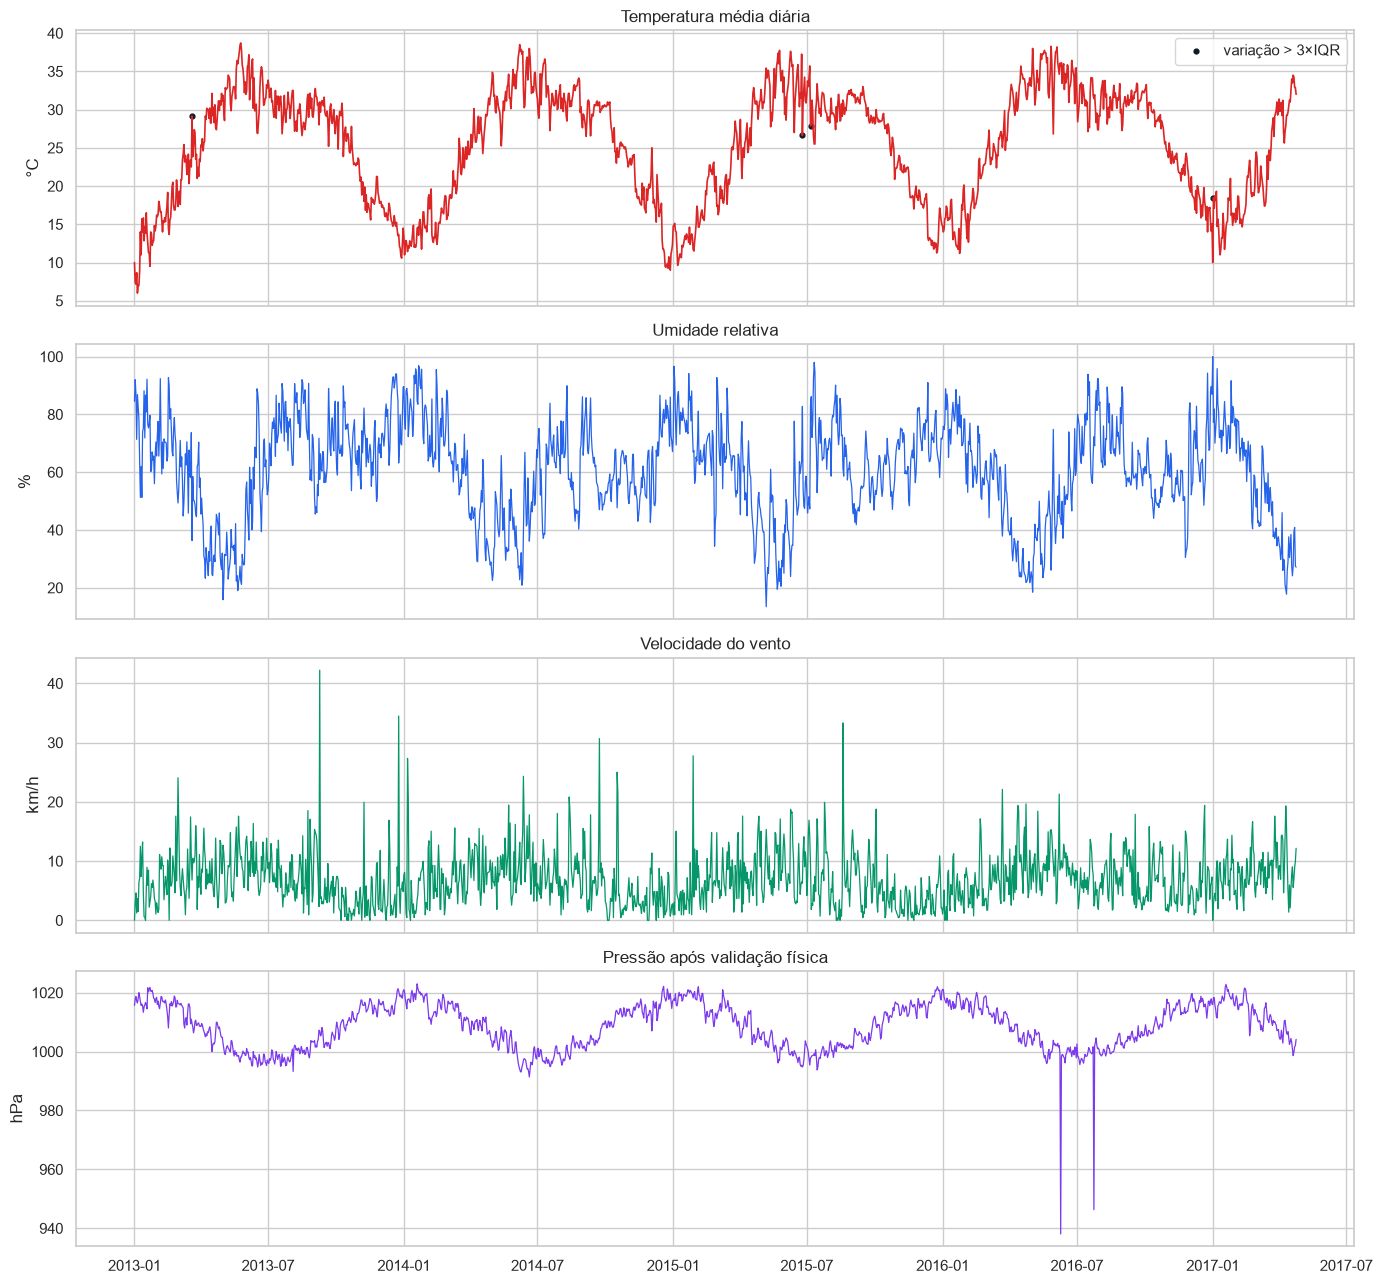

Série limpa salva: (1575, 5)


In [ ]:
raw = pd.read_csv(RAW_FILE)
expected_columns = ["date", "meantemp", "humidity", "wind_speed", "meanpressure"]
assert raw.columns.tolist() == expected_columns

df = raw.copy()
df["_source_order"] = np.arange(len(df))
df["date"] = pd.to_datetime(df["date"], errors="raise")
for column in expected_columns[1:]:
    df[column] = pd.to_numeric(df[column], errors="raise")

raw_duplicate_rows = int(df["date"].duplicated(keep=False).sum())
raw_duplicate_dates = int(df["date"].duplicated().sum())
df["_pressure_plausible"] = df["meanpressure"].between(900, 1100)
df = (
    df.sort_values(
        ["date", "_pressure_plausible", "_source_order"],
        ascending=[True, False, False],
    )
    .drop_duplicates("date", keep="first")
    .sort_values("date")
    .reset_index(drop=True)
)

invalid_pressure = ~df["meanpressure"].between(900, 1100)
invalid_pressure_dates = df.loc[invalid_pressure, "date"].dt.strftime("%Y-%m-%d").tolist()
df.loc[invalid_pressure, "meanpressure"] = np.nan
df["meanpressure"] = df["meanpressure"].ffill()

date_gaps = df["date"].diff().dropna().dt.days
integrity = {
    "raw_rows": len(raw),
    "clean_rows": len(df),
    "start": df["date"].min(),
    "end": df["date"].max(),
    "raw_duplicate_rows": raw_duplicate_rows,
    "raw_duplicate_dates": raw_duplicate_dates,
    "invalid_pressure_replaced": len(invalid_pressure_dates),
    "missing_after_cleaning": int(df[expected_columns].isna().sum().sum()),
    "duplicate_dates_after_cleaning": int(df["date"].duplicated().sum()),
    "non_daily_gaps": int((date_gaps != 1).sum()),
}
display(pd.Series(integrity, name="value").to_frame())
print("Datas com pressão inválida substituída por último valor passado:", invalid_pressure_dates)

assert integrity["missing_after_cleaning"] == 0
assert integrity["duplicate_dates_after_cleaning"] == 0
assert integrity["non_daily_gaps"] == 0
assert df["humidity"].between(0, 100).all()
assert (df["wind_speed"] >= 0).all()
assert df["meanpressure"].between(900, 1100).all()
assert df["meantemp"].between(-10, 55).all()

# Extremos de variação são informativos; não são removidos.
temperature_change = df["meantemp"].diff()
q1, q3 = temperature_change.quantile([0.25, 0.75])
iqr = q3 - q1
outlier_mask = (temperature_change < q1 - 3 * iqr) | (temperature_change > q3 + 3 * iqr)
print(f"Variações de temperatura fora de 3×IQR: {int(outlier_mask.sum())}; preservadas.")

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)
axes[0].plot(df["date"], df["meantemp"], color="#dc2626", linewidth=1.2)
axes[0].scatter(
    df.loc[outlier_mask, "date"],
    df.loc[outlier_mask, "meantemp"],
    s=12,
    color="#111827",
    label="variação > 3×IQR",
)
axes[0].legend()
axes[0].set(title="Temperatura média diária", ylabel="°C")
axes[1].plot(df["date"], df["humidity"], color="#2563eb", linewidth=0.9)
axes[1].set(title="Umidade relativa", ylabel="%")
axes[2].plot(df["date"], df["wind_speed"], color="#059669", linewidth=0.9)
axes[2].set(title="Velocidade do vento", ylabel="km/h")
axes[3].plot(df["date"], df["meanpressure"], color="#7c3aed", linewidth=0.9)
axes[3].set(title="Pressão após validação física", ylabel="hPa")
plt.tight_layout()
plt.show()

cleaned = df[expected_columns].copy()
cleaned.to_csv(DATA_DIR / f"cleaned_{BASE_ID}.csv", index=False)
assert (DATA_DIR / f"cleaned_{BASE_ID}.csv").exists()
print("Série limpa salva:", cleaned.shape)


### Decisões de limpeza

| Etapa | Decisão | Justificativa |
|---|---|---|
| Parse de data | `pd.to_datetime`, ordenação e frequência diária validada | preserva a ordem temporal real |
| Duplicidade | preferir, na data repetida, o registro com pressão entre 900 e 1100 hPa | regra determinística de integridade multivariada |
| Pressão impossível | converter para ausente e aplicar somente `ffill` | valores extremos são erros de medição; preenchimento não consulta o futuro |
| Outliers de temperatura | sinalizar pela primeira diferença e preservar | extremos climáticos podem ser reais |
| Alvo | manter temperatura em °C | MAE diretamente interpretável |

O raw não é regravado. Seu hash SHA-256 é conferido novamente na validação final.


## D. Estacionariedade, STL e força da sazonalidade

O teste final é separado antes destes diagnósticos. No desenvolvimento são comparados períodos `m ∈ {7, 30, 365}` para representar ciclos semanal, aproximadamente mensal e anual.

ACF/PACF e ADF são avaliados no nível, na primeira diferença e na diferença semanal. A decomposição STL é interpretada por tendência, sazonalidade e resíduo.


{'development_end': Timestamp('2017-02-20 00:00:00'), 'test_start': Timestamp('2017-02-21 00:00:00'), 'test_observations': 63}


,series,adf_stat,p_value,lags,n,crit_5pct,stationary_5pct
0,meantemp (nível),-2.358320,1.538474e-01,10,1501,-2.863467,False
1,meantemp (1ª diferença),-16.702934,1.456069e-29,9,1501,-2.863467,True
2,meantemp (diferença semanal),-5.524046,1.849875e-06,24,1480,-2.863495,True


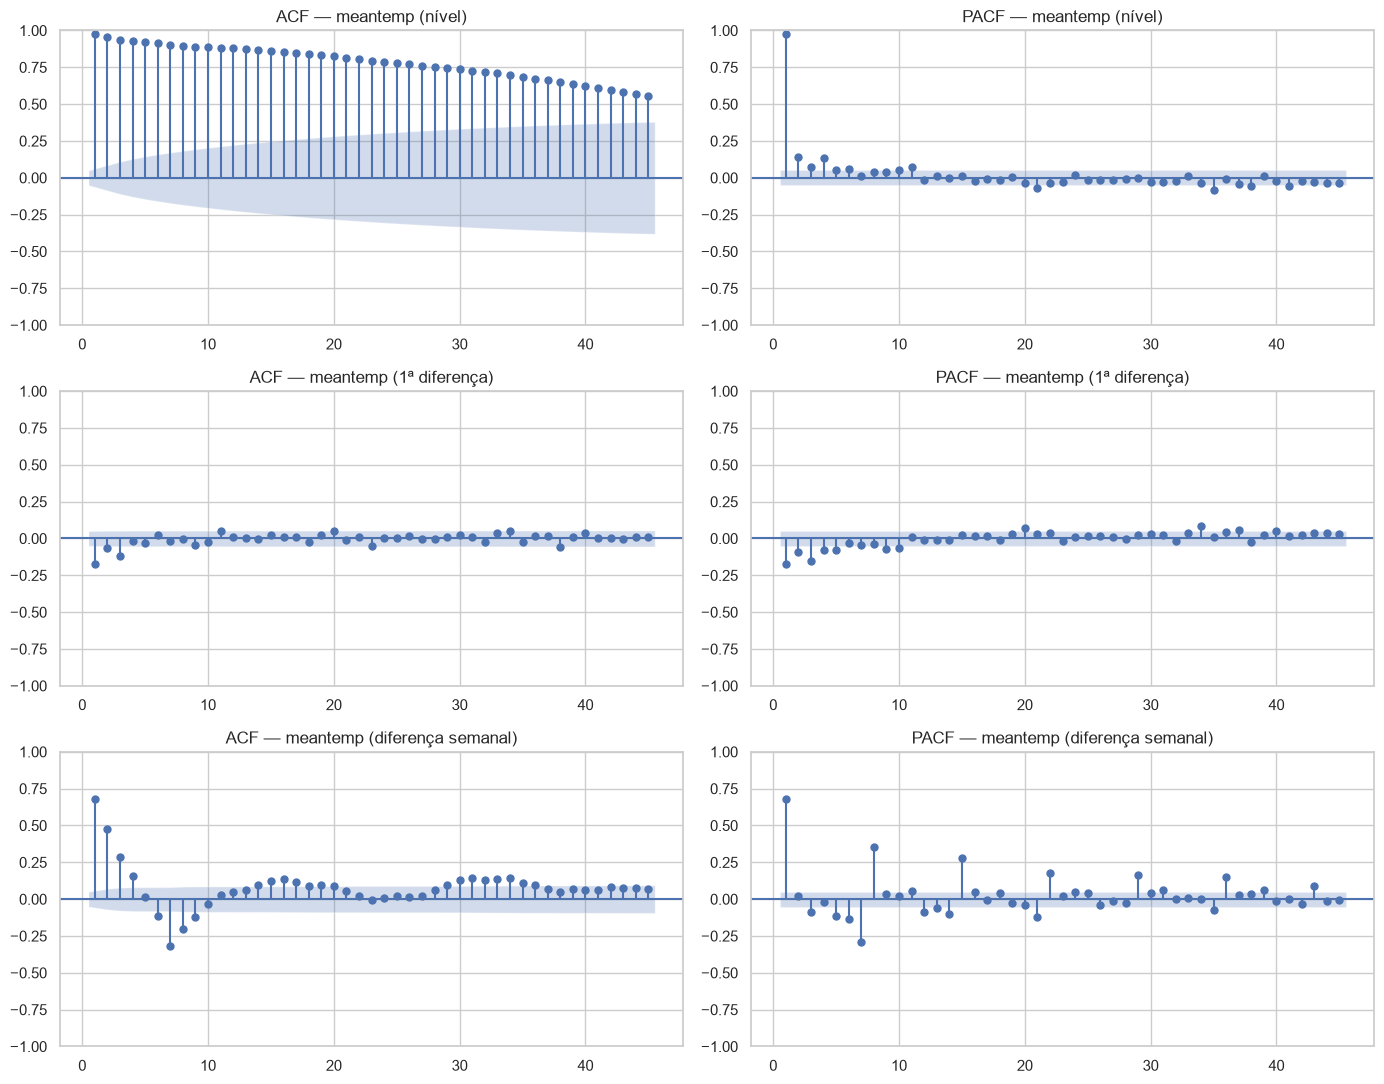

,m,seasonality_strength
2,365,0.932778
1,30,0.249543
0,7,0.040585


Maior força sazonal no desenvolvimento: m=365


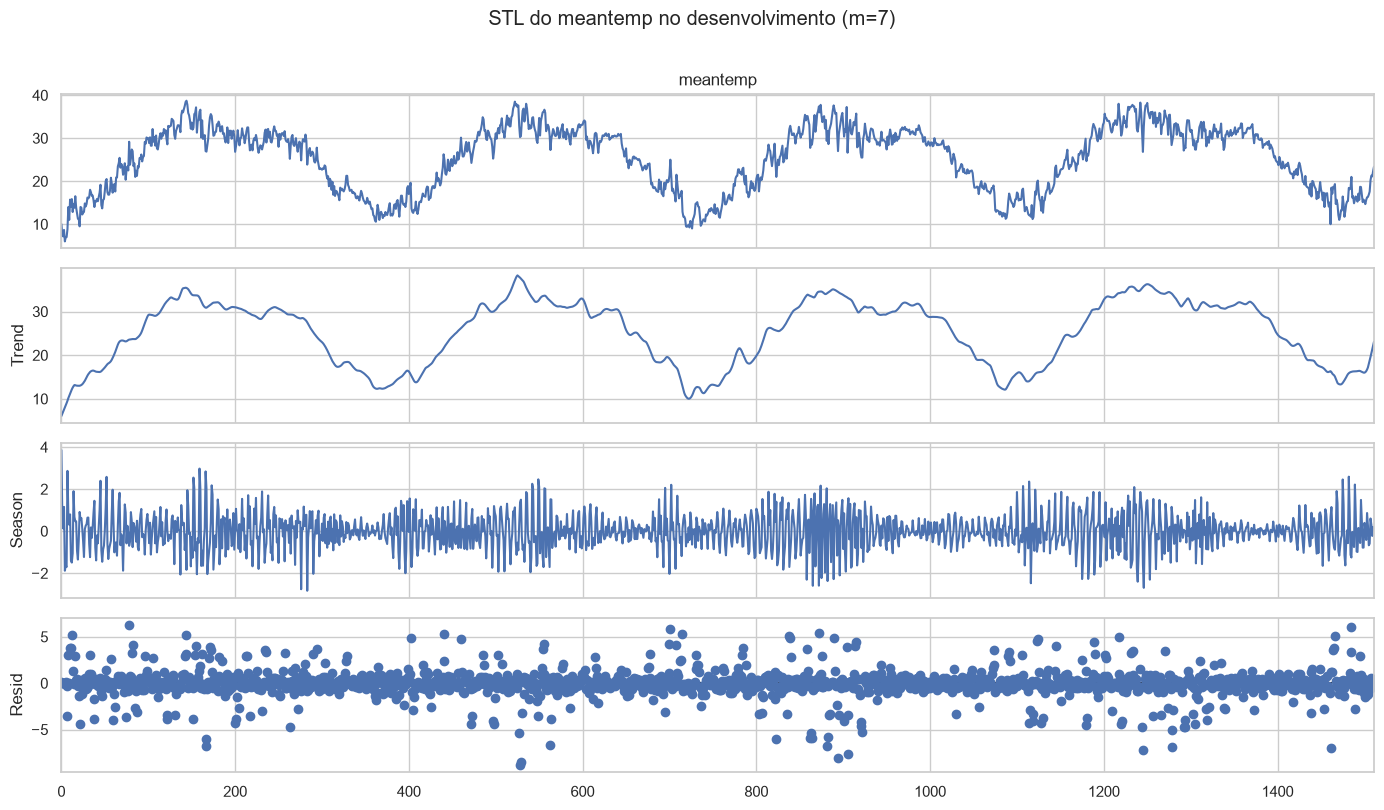

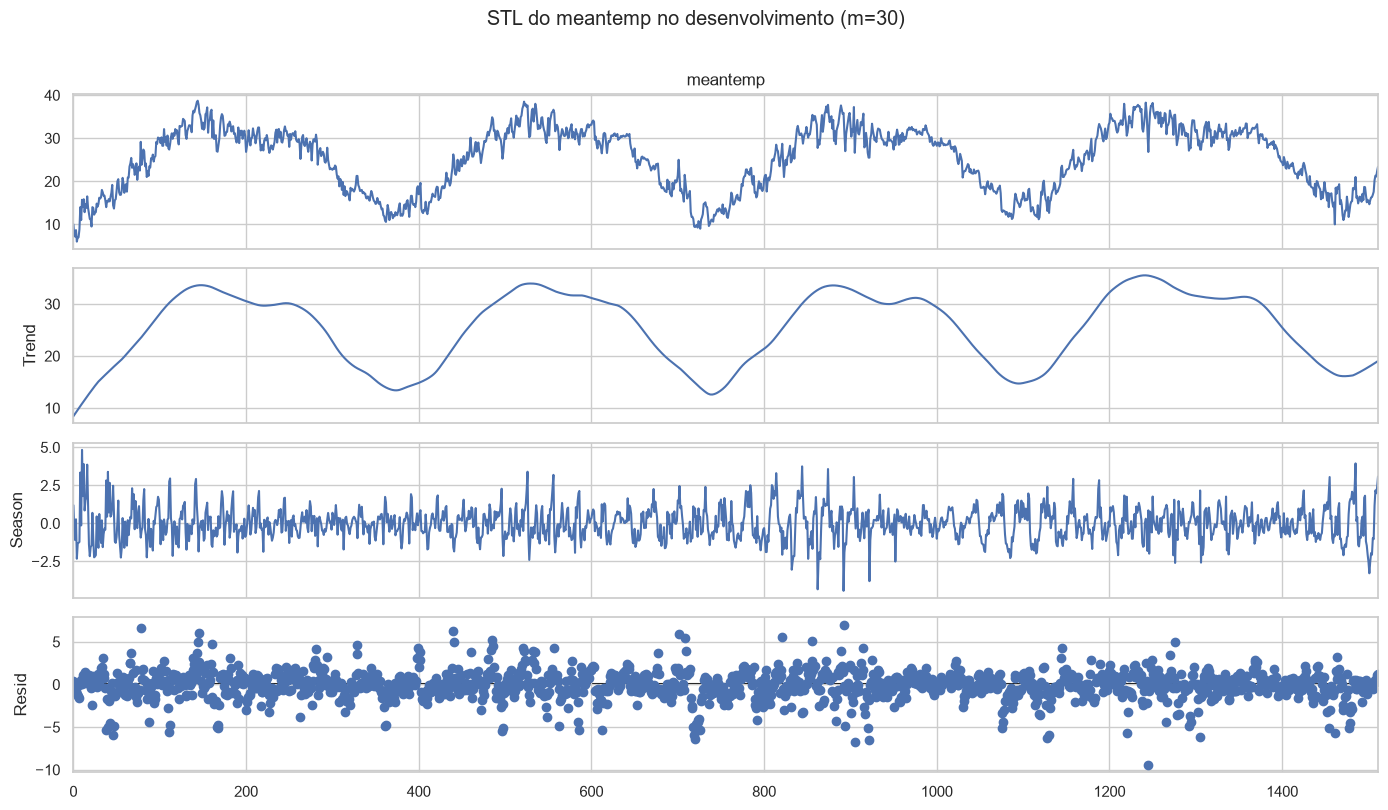

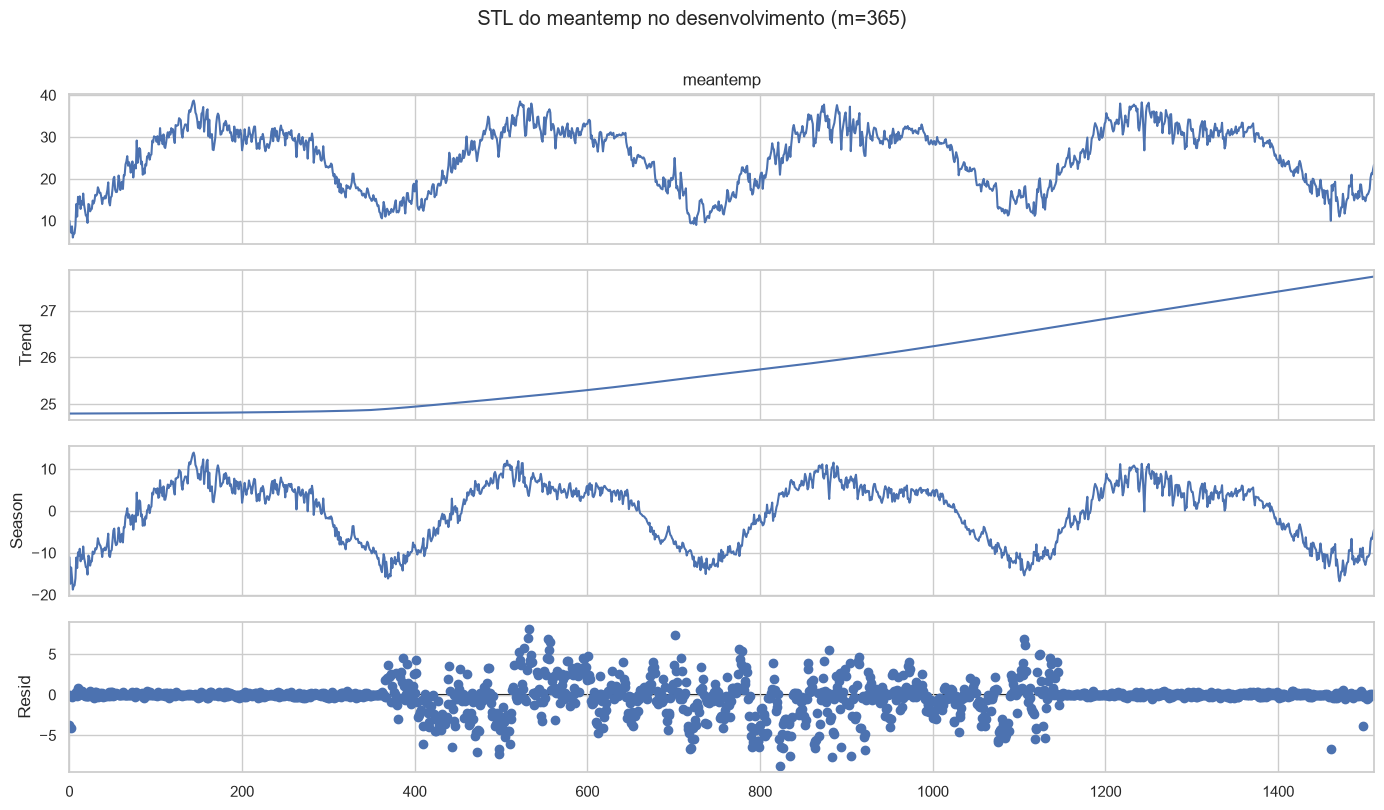

In [ ]:
HORIZON = 1
ORIGIN_STEP = 1
TRAIN_MIN_OBS = 365
TEST_OBS = 63
SEASONAL_PERIOD = 7
PERIOD_CANDIDATES = [7, 30, 365]

test_start_idx = len(cleaned) - TEST_OBS
development_end = cleaned.loc[test_start_idx - 1, "date"]
test_start = cleaned.loc[test_start_idx, "date"]
print({
    "development_end": development_end,
    "test_start": test_start,
    "test_observations": TEST_OBS,
})

development_target = cleaned.loc[:test_start_idx - 1, "meantemp"].reset_index(drop=True)


def adf_summary(series, name):
    values = pd.Series(series).dropna()
    stat, pvalue, usedlag, nobs, crit, _ = adfuller(values, autolag="AIC")
    return {
        "series": name,
        "adf_stat": float(stat),
        "p_value": float(pvalue),
        "lags": int(usedlag),
        "n": int(nobs),
        "crit_5pct": float(crit["5%"]),
        "stationary_5pct": bool(pvalue < 0.05),
    }


level = development_target
diff1 = development_target.diff().dropna()
diff7 = development_target.diff(7).dropna()
display(pd.DataFrame([
    adf_summary(level, "meantemp (nível)"),
    adf_summary(diff1, "meantemp (1ª diferença)"),
    adf_summary(diff7, "meantemp (diferença semanal)"),
]))

acf_lags = 45
fig, axes = plt.subplots(3, 2, figsize=(14, 11))
for row, (series, title) in enumerate([
    (level, "meantemp (nível)"),
    (diff1, "meantemp (1ª diferença)"),
    (diff7, "meantemp (diferença semanal)"),
]):
    plot_acf(series, lags=acf_lags, ax=axes[row, 0], zero=False)
    plot_pacf(series, lags=acf_lags, ax=axes[row, 1], zero=False, method="ywm")
    axes[row, 0].set_title(f"ACF — {title}")
    axes[row, 1].set_title(f"PACF — {title}")
plt.tight_layout()
plt.show()

seasonality_rows = []
stl_by_period = {}
for period in PERIOD_CANDIDATES:
    fitted = STL(development_target, period=period, robust=True).fit()
    strength = max(
        0.0,
        1.0 - np.var(fitted.resid, ddof=1) / np.var(fitted.seasonal + fitted.resid, ddof=1),
    )
    stl_by_period[period] = fitted
    seasonality_rows.append({"m": period, "seasonality_strength": float(strength)})

seasonality_table = pd.DataFrame(seasonality_rows).sort_values(
    "seasonality_strength", ascending=False
)
display(seasonality_table)
best_m = int(seasonality_table.iloc[0]["m"])
print(f"Maior força sazonal no desenvolvimento: m={best_m}")

for period in PERIOD_CANDIDATES:
    fig = stl_by_period[period].plot()
    fig.set_size_inches(14, 8)
    plt.suptitle(f"STL do meantemp no desenvolvimento (m={period})", y=1.01)
    plt.tight_layout()
    plt.show()


A série em nível não é estacionária pelo ADF (`p=0,154`), enquanto a primeira diferença e a diferença semanal são estacionárias (`p<0,001`). A decomposição confirma que o ciclo dominante é anual: a força sazonal foi `0,933` para `m=365`, contra `0,250` para `m=30` e `0,041` para `m=7`.

Por custo computacional, o SARIMAX representa o ciclo anual com seno/cosseno do dia do ano e mantém a busca sazonal direta em `m=7`. O Holt-Winters testou o período anual, mas a validação temporal selecionou tendência e sazonalidade aditivas semanais.

## E. Feature engineering e contrato anti-vazamento

Features comuns ao Random Forest e Elastic Net:

- alvo: lags de 1, 2, 3, 7, 14, 30 e 365 dias;
- externas: lags de 1, 2, 7 e 30 dias para umidade, vento e pressão;
- janelas fechadas na origem: média e desvio da temperatura em 7, 30 e 365 dias;
- mudanças de temperatura observadas em 1 e 7 dias;
- calendário da data prevista: mês, dia da semana e dia do ano;
- seno/cosseno semanal e anual.

As primeiras linhas incompletas são descartadas, sem imputação. `observed_source_max_date` explicita a data mais recente consultada por features observadas.


In [ ]:
TARGET = "meantemp"
EXTERNALS = ["humidity", "wind_speed", "meanpressure"]


def build_samples(frame):
    indexed = frame.copy().set_index("date")
    target = indexed[TARGET]
    samples = pd.DataFrame(index=indexed.index)
    samples["origin_date"] = samples.index.to_series().shift(1)
    samples["forecast_date"] = samples.index
    samples["horizon_step"] = HORIZON

    for lag in [1, 2, 3, 7, 14, 30, 365]:
        samples[f"target_lag_{lag}"] = target.shift(lag)
    for column in EXTERNALS:
        for lag in [1, 2, 7, 30]:
            samples[f"{column}_lag_{lag}"] = indexed[column].shift(lag)

    shifted_target = target.shift(1)
    for window in [7, 30, 365]:
        samples[f"target_mean_{window}"] = shifted_target.rolling(window).mean()
        samples[f"target_std_{window}"] = shifted_target.rolling(window).std()

    samples["target_change_1"] = target.shift(1) - target.shift(2)
    samples["target_change_7"] = target.shift(1) - target.shift(8)

    forecast_dates = pd.Series(samples.index, index=samples.index)
    dow = forecast_dates.dt.dayofweek
    doy = forecast_dates.dt.dayofyear
    samples["month"] = forecast_dates.dt.month
    samples["day_of_week"] = dow
    samples["day_of_year"] = doy
    samples["week_sin"] = np.sin(2 * np.pi * dow / 7)
    samples["week_cos"] = np.cos(2 * np.pi * dow / 7)
    samples["year_sin"] = np.sin(2 * np.pi * doy / 365.25)
    samples["year_cos"] = np.cos(2 * np.pi * doy / 365.25)
    samples["observed_source_max_date"] = samples["origin_date"]
    samples["target"] = target
    return samples.dropna().reset_index(drop=True)


samples = build_samples(cleaned)
key_cols = ["origin_date", "forecast_date", "horizon_step"]
audit_cols = ["observed_source_max_date"]
feature_cols = [
    column
    for column in samples.columns
    if column not in key_cols + audit_cols + ["target"]
]

assert (samples["observed_source_max_date"] <= samples["origin_date"]).all()
assert (samples["origin_date"] < samples["forecast_date"]).all()
assert samples[key_cols].duplicated().sum() == 0
assert not samples[feature_cols + ["target"]].isna().any().any()

samples.to_parquet(DATA_DIR / f"features_{BASE_ID}.parquet", index=False)
roundtrip = pd.read_parquet(DATA_DIR / f"features_{BASE_ID}.parquet")
assert roundtrip.shape == samples.shape
print(f"{len(feature_cols)} features; {len(samples)} amostras; anti-leakage validado.")
display(samples.head(3))


34 features; 1210 amostras; anti-leakage validado.


,origin_date,forecast_date,horizon_step,target_lag_1,target_lag_2,target_lag_3,target_lag_7,target_lag_14,target_lag_30,target_lag_365,...,target_change_7,month,day_of_week,day_of_year,week_sin,week_cos,year_sin,year_cos,observed_source_max_date,target
0,2013-12-31,2014-01-01,1,14.500,12.375,10.571429,13.666667,14.875,17.250000,10.000000,...,1.000000,1,2,1,0.974928,-0.222521,0.017202,0.999852,2013-12-31,13.375
1,2014-01-01,2014-01-02,1,13.375,14.500,12.375000,12.125000,16.125,17.500000,7.400000,...,-0.291667,1,3,2,0.433884,-0.900969,0.034398,0.999408,2014-01-01,11.000
2,2014-01-02,2014-01-03,1,11.000,13.375,14.500000,11.875000,15.375,17.142857,7.166667,...,-1.125000,1,4,3,-0.433884,-0.900969,0.051584,0.998669,2014-01-02,12.500


Checklist anti-vazamento:

- [x] toda feature observada possui `observed_source_max_date <= origin_date`;
- [x] temperatura, umidade, vento e pressão do dia previsto não são usados;
- [x] janelas móveis recebem `shift(1)` antes do `rolling`;
- [x] calendário usa somente `forecast_date` e é conhecido antecipadamente;
- [x] scaler do Elastic Net está dentro de `Pipeline`;
- [x] RF e Elastic Net usam exatamente `feature_cols`;
- [x] o teste final foi separado antes do tuning.


## F. Tuning temporal e motor walk-forward

O desenvolvimento termina antes dos últimos 63 dias. O teste final nunca entra na busca.

- **SARIMAX:** grid temporal expansivo de `(p,d,q)` e termos semanais, com lags das externas e harmônicos anuais.
- **Holt-Winters:** tendência ausente/aditiva, amortecimento, sazonalidade aditiva/multiplicativa e períodos 7/365. Tendência multiplicativa é excluída por instabilidade numérica observada no walk-forward.
- **Random Forest e Elastic Net:** `GridSearchCV` com `TimeSeriesSplit(5)` e MAE negativo.

Os hiperparâmetros selecionados são congelados antes do walk-forward. Esta seção é a mais demorada do notebook.


In [ ]:
development = samples[samples["forecast_date"] < test_start].reset_index(drop=True)
test_samples = samples[samples["forecast_date"] >= test_start].reset_index(drop=True)
assert development["forecast_date"].max() <= development_end
assert test_samples["forecast_date"].min() == test_start
assert len(test_samples) == TEST_OBS

sarimax_features = [
    "humidity_lag_1",
    "wind_speed_lag_1",
    "meanpressure_lag_1",
    "year_sin",
    "year_cos",
]


def jsonable(obj):
    if isinstance(obj, dict):
        return {str(key): jsonable(value) for key, value in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [jsonable(value) for value in obj]
    if isinstance(obj, (np.floating, np.integer)):
        return obj.item()
    if obj is None or isinstance(obj, (str, bool, int, float)):
        return obj
    return str(obj)


def expanding_origins(n, count=4, validation_size=56):
    start = max(TRAIN_MIN_OBS, n - validation_size)
    return np.unique(np.linspace(start, n - 1, count, dtype=int))


def tune_stats_model(model_name, candidates):
    records = []
    origins = expanding_origins(len(development))
    print(f"{model_name}: {len(candidates)} configurações × {len(origins)} origens")
    for candidate_number, params in enumerate(candidates, start=1):
        errors = []
        for index in origins:
            train = development.iloc[:index]
            valid = development.iloc[index:index + 1]
            try:
                if model_name == "sarimax":
                    fitted = SARIMAX(
                        train["target"],
                        exog=train[sarimax_features],
                        order=tuple(params["order"]),
                        seasonal_order=tuple(params["seasonal_order"]),
                        trend=params["trend"],
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    ).fit(disp=False, maxiter=75)
                    prediction = fitted.forecast(
                        1, exog=valid[sarimax_features].astype(float)
                    ).iloc[0]
                else:
                    seasonal = params["seasonal"]
                    fitted = ExponentialSmoothing(
                        train["target"].to_numpy(),
                        trend=params["trend"],
                        damped_trend=params["damped_trend"],
                        seasonal=seasonal,
                        seasonal_periods=params["seasonal_periods"] if seasonal else None,
                        initialization_method="estimated",
                    ).fit(optimized=True)
                    prediction = fitted.forecast(1)[0]
                if not np.isfinite(prediction):
                    raise FloatingPointError("Previsão não finita no tuning.")
                errors.append(abs(valid["target"].iloc[0] - prediction))
            except Exception:
                errors.append(np.inf)
        records.append({
            "params": jsonable(params),
            "validation_mae": float(np.mean(errors)),
            "n_failed_origins": int(np.isinf(errors).sum()),
        })
        if candidate_number % 20 == 0 or candidate_number == len(candidates):
            print(f"  {model_name} {candidate_number}/{len(candidates)}")
    valid_records = [row for row in records if np.isfinite(row["validation_mae"])]
    if not valid_records:
        raise RuntimeError(f"Nenhuma configuração válida para {model_name}.")
    return sorted(valid_records, key=lambda row: row["validation_mae"])


sarimax_candidates = []
weekly_orders = [(0, 0, 0, 7), (1, 0, 0, 7), (0, 0, 1, 7), (1, 0, 1, 7)]
for order in product([0, 1, 2], [0, 1], [0, 1]):
    for seasonal_order in weekly_orders:
        sarimax_candidates.append({
            "order": order,
            "seasonal_order": seasonal_order,
            "trend": "c",
        })

hw_candidates = []
for trend in [None, "add"]:
    damped_options = [False] if trend is None else [False, True]
    for damped_trend in damped_options:
        hw_candidates.append({
            "trend": trend,
            "damped_trend": damped_trend,
            "seasonal": None,
            "seasonal_periods": None,
        })
        for seasonal, period in product(["add", "mul"], [7, 365]):
            hw_candidates.append({
                "trend": trend,
                "damped_trend": damped_trend,
                "seasonal": seasonal,
                "seasonal_periods": period,
            })

sarimax_search = tune_stats_model("sarimax", sarimax_candidates)
hw_search = tune_stats_model("holt_winters", hw_candidates)
sarimax_params = sarimax_search[0]["params"]
hw_params = hw_search[0]["params"]

cv = TimeSeriesSplit(n_splits=5)
rf_base = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)
rf_grid = {
    "n_estimators": [200, 400],
    "max_depth": [8, 16, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 3],
    "max_features": ["sqrt", 0.7],
}
en_base = Pipeline([
    ("scaler", StandardScaler()),
    ("model", ElasticNet(max_iter=20000, random_state=RANDOM_STATE)),
])
en_grid = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 0.5, 1.0],
    "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9, 1.0],
}

rf_gs = GridSearchCV(
    rf_base,
    rf_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
rf_gs.fit(development[feature_cols], development["target"])

en_gs = GridSearchCV(
    en_base,
    en_grid,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
en_gs.fit(development[feature_cols], development["target"])

rf_params = rf_gs.best_params_
en_params = en_gs.best_params_


def sklearn_search_table(search):
    cv_results = pd.DataFrame(search.cv_results_)
    table = cv_results[["params", "mean_test_score", "rank_test_score"]].copy()
    table["validation_mae"] = -table["mean_test_score"]
    table = table.sort_values("rank_test_score")
    return [
        {
            "params": jsonable(row.params),
            "validation_mae": float(row.validation_mae),
            "rank": int(row.rank_test_score),
        }
        for row in table.itertuples(index=False)
    ]


rf_search = sklearn_search_table(rf_gs)
en_search = sklearn_search_table(en_gs)
searches = {
    "sarimax": (sarimax_search, sarimax_params),
    "holt_winters": (hw_search, hw_params),
    "random_forest": (rf_search, rf_params),
    "elastic_net": (en_search, en_params),
}

for model_name, (search, selected) in searches.items():
    payload = {
        "base_id": BASE_ID,
        "dataset": DATASET_NAME,
        "model": model_name,
        "method": (
            "expanding temporal grid search"
            if model_name in ["sarimax", "holt_winters"]
            else "GridSearchCV + TimeSeriesSplit(n_splits=5)"
        ),
        "tuning_end": str(development_end.date()),
        "test_start": str(test_start.date()),
        "n_candidates": len(search),
        "search_results": search[:30],
        "selected": jsonable(selected),
        "criterion": "menor MAE médio na validação temporal",
    }
    with open(
        DATA_DIR / f"hyperparams_{model_name}_{BASE_ID}.json",
        "w",
        encoding="utf-8",
    ) as stream:
        json.dump(payload, stream, indent=2, ensure_ascii=False)
    print(model_name, selected, "validation_mae=", round(search[0]["validation_mae"], 4))


sarimax: 48 configurações × 4 origens


  sarimax 20/48


  sarimax 40/48


  sarimax 48/48
holt_winters: 15 configurações × 4 origens


  holt_winters 15/15
Fitting 5 folds for each of 48 candidates, totalling 240 fits


Fitting 5 folds for each of 36 candidates, totalling 180 fits


sarimax {'order': [0, 1, 0], 'seasonal_order': [0, 0, 0, 7], 'trend': 'c'} validation_mae= 0.4843
holt_winters {'trend': 'add', 'damped_trend': False, 'seasonal': 'add', 'seasonal_periods': 7} validation_mae= 0.6215
random_forest {'max_depth': None, 'max_features': 0.7, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 200} validation_mae= 1.3761
elastic_net {'model__alpha': 0.5, 'model__l1_ratio': 1.0} validation_mae= 1.3224


In [ ]:
def fit_predict_one(model_name, train, current):
    fit_start = time.perf_counter()
    if model_name == "sarimax":
        model = SARIMAX(
            train["target"],
            exog=train[sarimax_features],
            order=tuple(sarimax_params["order"]),
            seasonal_order=tuple(sarimax_params["seasonal_order"]),
            trend=sarimax_params["trend"],
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False, maxiter=75)
    elif model_name == "holt_winters":
        model = ExponentialSmoothing(
            train["target"].to_numpy(),
            trend=hw_params["trend"],
            damped_trend=hw_params["damped_trend"],
            seasonal=hw_params["seasonal"],
            seasonal_periods=hw_params.get("seasonal_periods"),
            initialization_method="estimated",
        ).fit(optimized=True)
    elif model_name == "random_forest":
        model = clone(rf_base).set_params(**rf_params)
        model.fit(train[feature_cols], train["target"])
    else:
        model = clone(en_base).set_params(**en_params)
        model.fit(train[feature_cols], train["target"])
    fit_seconds = time.perf_counter() - fit_start

    predict_start = time.perf_counter()
    if model_name == "sarimax":
        prediction = float(
            model.forecast(1, exog=current[sarimax_features].astype(float)).iloc[0]
        )
    elif model_name == "holt_winters":
        prediction = float(model.forecast(1)[0])
    else:
        prediction = float(model.predict(current[feature_cols].astype(float))[0])
    if not np.isfinite(prediction):
        raise FloatingPointError(f"Previsão não finita para {model_name}.")
    predict_seconds = time.perf_counter() - predict_start
    return prediction, fit_seconds, predict_seconds


model_names = ["sarimax", "holt_winters", "random_forest", "elastic_net"]
predictions = {}
for model_name in model_names:
    rows = []
    for _, current_row in test_samples.iterrows():
        current = current_row.to_frame().T
        origin = current_row["origin_date"]
        train = samples[samples["forecast_date"] <= origin]
        assert len(train) >= TRAIN_MIN_OBS
        assert train["forecast_date"].max() <= origin
        assert current_row["observed_source_max_date"] <= origin
        prediction, fit_seconds, predict_seconds = fit_predict_one(
            model_name, train, current
        )
        rows.append({
            "origin_date": origin,
            "forecast_date": current_row["forecast_date"],
            "horizon_step": HORIZON,
            "y_true": current_row["target"],
            "y_pred": prediction,
            "fit_seconds": fit_seconds,
            "predict_seconds": predict_seconds,
        })
    prediction_frame = pd.DataFrame(rows)
    prediction_frame.to_csv(
        DATA_DIR / f"predictions_{model_name}_{BASE_ID}.csv", index=False
    )
    predictions[model_name] = prediction_frame
    print(model_name, len(prediction_frame), "previsões")

reference_keys = predictions[model_names[0]][key_cols].reset_index(drop=True)
for model_name in model_names[1:]:
    pd.testing.assert_frame_equal(
        reference_keys,
        predictions[model_name][key_cols].reset_index(drop=True),
    )
assert len({len(frame) for frame in predictions.values()}) == 1
print("Conformidade: chaves OOS idênticas nos quatro modelos.")


sarimax 63 previsões


holt_winters 63 previsões


random_forest 63 previsões


elastic_net 63 previsões
Conformidade: chaves OOS idênticas nos quatro modelos.


## G. MAE, ranking e gráficos de avaliação

O MAE abaixo usa exclusivamente as 63 previsões fora da amostra do walk-forward. Os gráficos comparam temperatura observada e prevista, dispersão e ranking. Não há agregação com outras bases.


,base_id,model,mae,rank,n_predictions
0,base_02,sarimax,1.256775,1,63
1,base_02,random_forest,1.256998,2,63
2,base_02,holt_winters,1.301291,3,63
3,base_02,elastic_net,1.442940,4,63


Vencedor nesta base: sarimax


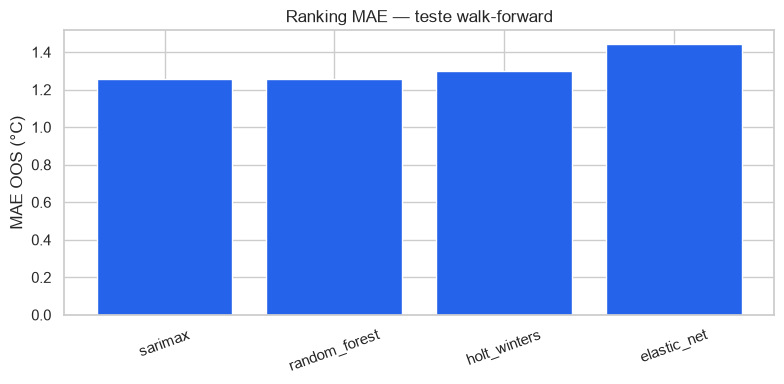

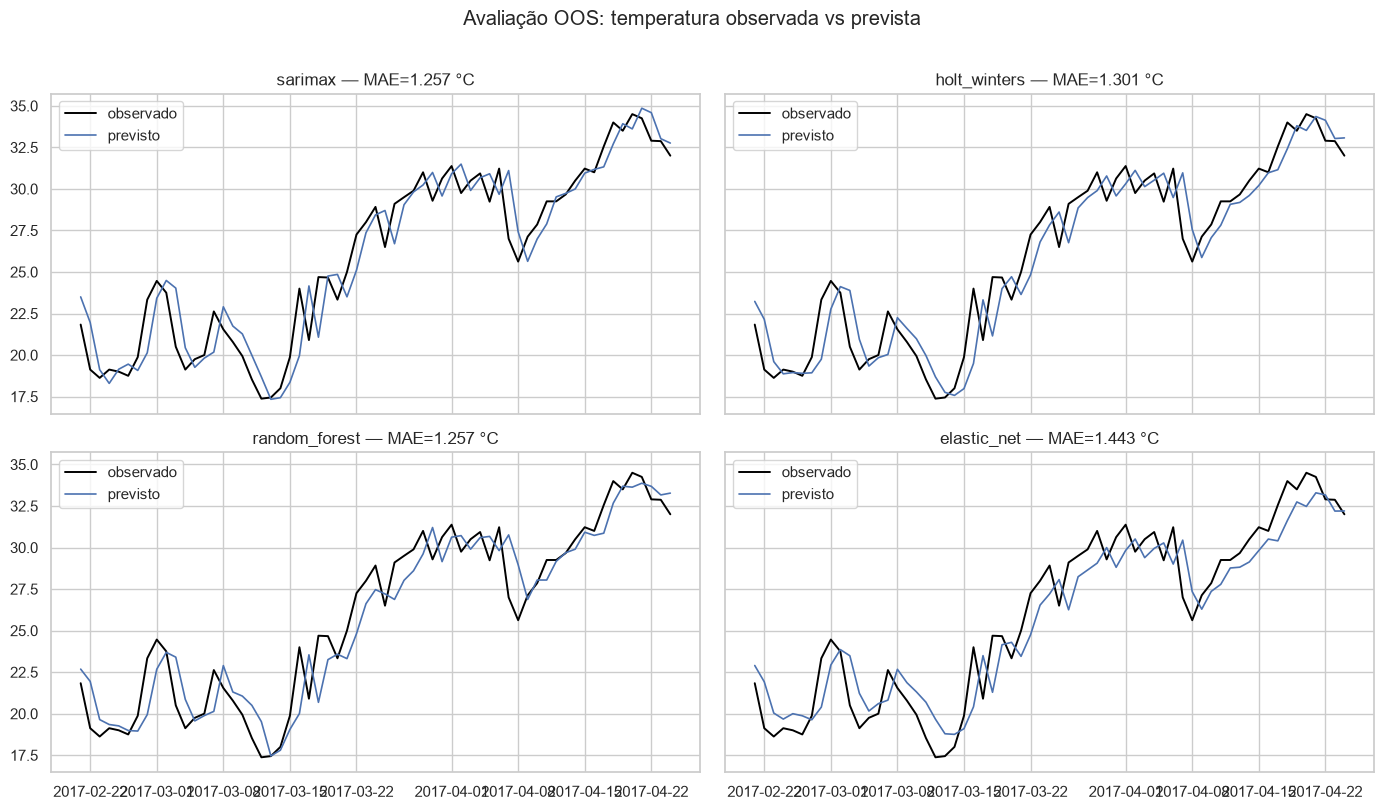

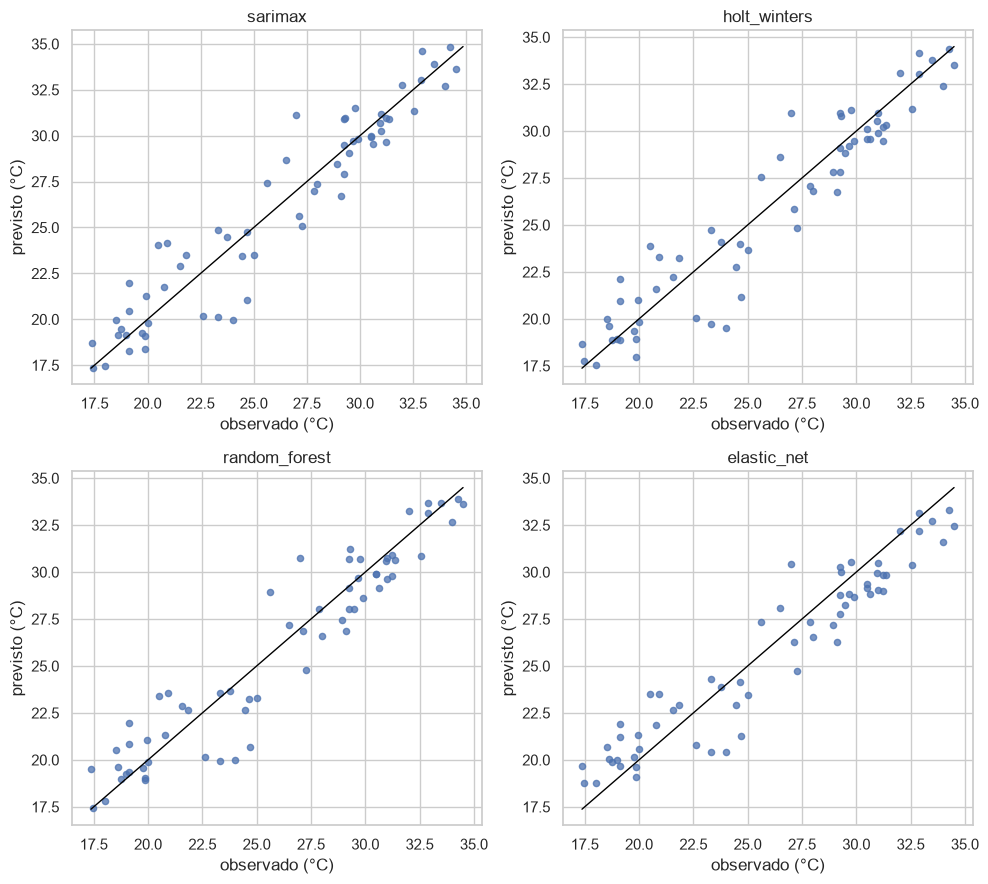

In [ ]:
mae_rows = []
for model_name, prediction_frame in predictions.items():
    assert np.isfinite(prediction_frame[["y_true", "y_pred"]].to_numpy()).all()
    score = float(np.mean(np.abs(
        prediction_frame["y_true"] - prediction_frame["y_pred"]
    )))
    mae_rows.append({
        "base_id": BASE_ID,
        "model": model_name,
        "mae": score,
        "n_predictions": len(prediction_frame),
    })

mae_table = pd.DataFrame(mae_rows).sort_values("mae").reset_index(drop=True)
mae_table["rank"] = np.arange(1, len(mae_table) + 1)
mae_table = mae_table[["base_id", "model", "mae", "rank", "n_predictions"]]
mae_table.to_csv(DATA_DIR / f"mae_{BASE_ID}.csv", index=False)
display(mae_table)
print("Vencedor nesta base:", mae_table.iloc[0]["model"])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(mae_table["model"], mae_table["mae"], color="#2563eb")
ax.set(ylabel="MAE OOS (°C)", title="Ranking MAE — teste walk-forward")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for ax, model_name in zip(axes.ravel(), model_names):
    prediction_frame = predictions[model_name]
    model_mae = mae_table.loc[mae_table["model"] == model_name, "mae"].iloc[0]
    ax.plot(
        prediction_frame["forecast_date"],
        prediction_frame["y_true"],
        label="observado",
        color="black",
        linewidth=1.4,
    )
    ax.plot(
        prediction_frame["forecast_date"],
        prediction_frame["y_pred"],
        label="previsto",
        linewidth=1.2,
    )
    ax.set_title(f"{model_name} — MAE={model_mae:.3f} °C")
    ax.legend(loc="upper left")
fig.suptitle("Avaliação OOS: temperatura observada vs prevista", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for ax, model_name in zip(axes.ravel(), model_names):
    prediction_frame = predictions[model_name]
    ax.scatter(prediction_frame["y_true"], prediction_frame["y_pred"], s=20, alpha=0.75)
    low = min(prediction_frame["y_true"].min(), prediction_frame["y_pred"].min())
    high = max(prediction_frame["y_true"].max(), prediction_frame["y_pred"].max())
    ax.plot([low, high], [low, high], color="black", linewidth=1)
    ax.set(xlabel="observado (°C)", ylabel="previsto (°C)", title=model_name)
plt.tight_layout()
plt.show()


O SARIMAX venceu com MAE de `1,256775 °C`, praticamente empatado com o Random Forest (`1,256998 °C`; diferença de apenas `0,000223 °C`). Holt-Winters ficou em terceiro (`1,301291 °C`) e Elastic Net em quarto (`1,442940 °C`). Todos foram avaliados nas mesmas 63 datas.

A proximidade entre SARIMAX e Random Forest recomenda tratar o ranking com cautela: nesta janela, a vantagem numérica do primeiro é mínima. A forte persistência térmica explica o desempenho dos modelos que exploram diretamente o passado recente.

## H. Resíduos OOS, ACF, PACF e Ljung–Box

Como `h=1` e a origem avança um dia, os resíduos formam uma sequência temporal sem sobreposição de horizontes. Média, série, histograma, ACF, PACF e Ljung–Box ajudam a identificar viés, assimetria e dependência remanescente.


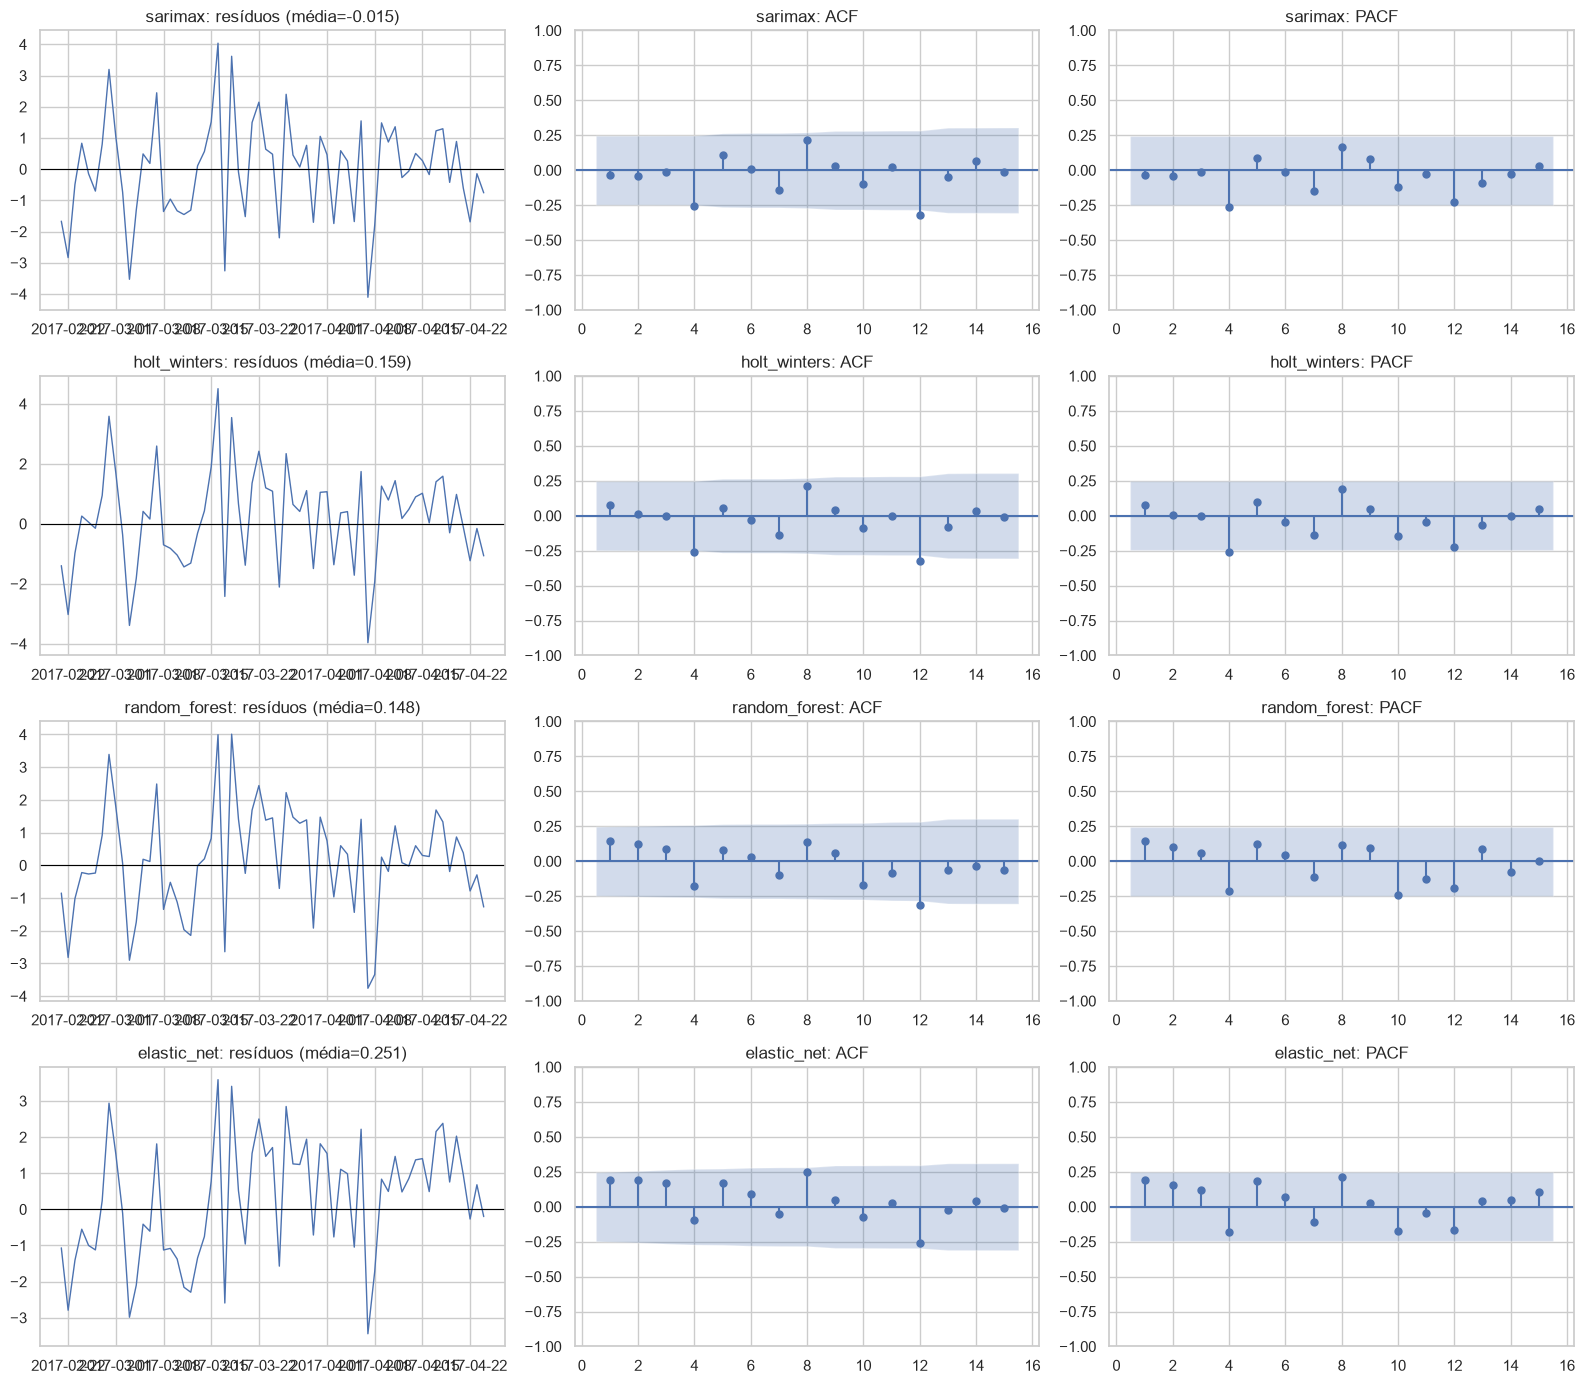

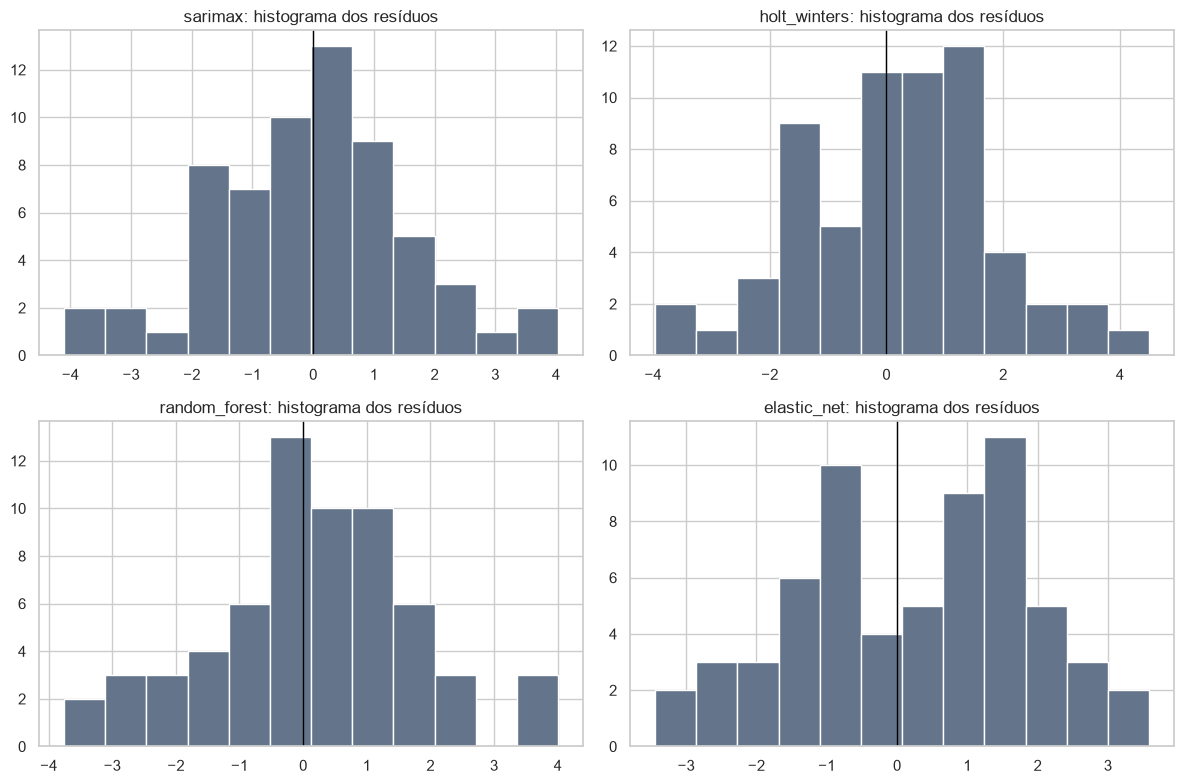

,base_id,model,horizon_step,lag,lb_stat,p_value,n_residuals
0,base_02,sarimax,1,7,7.010264,0.427812,63
1,base_02,sarimax,1,14,20.041869,0.128827,63
2,base_02,holt_winters,1,7,6.559467,0.476140,63
3,base_02,holt_winters,1,14,19.910903,0.132976,63
4,base_02,random_forest,1,7,6.350674,0.499451,63
5,base_02,random_forest,1,14,19.233493,0.156218,63
6,base_02,elastic_net,1,7,10.331206,0.170568,63
7,base_02,elastic_net,1,14,21.198137,0.096662,63


p < 0,05 indica evidência de autocorrelação residual no lag correspondente.


In [ ]:
ljung_rows = []
fig, axes = plt.subplots(len(model_names), 3, figsize=(16, 14))
for row_index, model_name in enumerate(model_names):
    prediction_frame = predictions[model_name].copy()
    prediction_frame["residual"] = (
        prediction_frame["y_true"] - prediction_frame["y_pred"]
    )
    residual_columns = key_cols + ["y_true", "y_pred", "residual"]
    prediction_frame[residual_columns].to_csv(
        DATA_DIR / f"residuals_{model_name}_{BASE_ID}.csv", index=False
    )

    residuals = prediction_frame["residual"]
    assert np.isfinite(residuals.to_numpy()).all()
    residual_lags = min(15, max(7, len(residuals) // 4))
    axes[row_index, 0].plot(
        prediction_frame["forecast_date"], residuals, linewidth=1
    )
    axes[row_index, 0].axhline(0, color="black", linewidth=0.8)
    axes[row_index, 0].set_title(
        f"{model_name}: resíduos (média={residuals.mean():.3f})"
    )
    plot_acf(residuals, lags=residual_lags, ax=axes[row_index, 1], zero=False)
    axes[row_index, 1].set_title(f"{model_name}: ACF")
    plot_pacf(
        residuals,
        lags=residual_lags,
        ax=axes[row_index, 2],
        zero=False,
        method="ywm",
    )
    axes[row_index, 2].set_title(f"{model_name}: PACF")

    for lag in [7, 14]:
        ljung = acorr_ljungbox(residuals, lags=[lag], return_df=True).iloc[0]
        ljung_rows.append({
            "base_id": BASE_ID,
            "model": model_name,
            "horizon_step": HORIZON,
            "lag": lag,
            "lb_stat": float(ljung["lb_stat"]),
            "p_value": float(ljung["lb_pvalue"]),
            "n_residuals": len(residuals),
        })
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, model_name in zip(axes.ravel(), model_names):
    residuals = predictions[model_name]["y_true"] - predictions[model_name]["y_pred"]
    ax.hist(residuals, bins=12, color="#64748b", edgecolor="white")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"{model_name}: histograma dos resíduos")
plt.tight_layout()
plt.show()

ljung_table = pd.DataFrame(ljung_rows)
ljung_table.to_csv(DATA_DIR / f"ljung_box_{BASE_ID}.csv", index=False)
display(ljung_table)
print("p < 0,05 indica evidência de autocorrelação residual no lag correspondente.")


Nenhum modelo apresentou evidência de autocorrelação residual nos lags 7 ou 14 (`p>0,05` em todos os testes). O SARIMAX teve viés médio praticamente nulo (`-0,015 °C`). Holt-Winters (`0,159 °C`), Random Forest (`0,148 °C`) e Elastic Net (`0,251 °C`) mostraram leve subprevisão média.

Os resultados não provam independência completa, mas não permitem rejeitar a hipótese de ruído branco nos lags avaliados. A leitura conjunta dos gráficos continua necessária para identificar mudanças de variância e extremos.

## I. Importância e persistência dos modelos finais

Após congelar as métricas OOS, os modelos finais são reajustados com todas as amostras disponíveis. Isso serve à persistência operacional e não altera as previsões históricas.

A importância por permutação é calculada com o Random Forest ajustado somente no desenvolvimento e avaliado no teste, evitando usar um modelo que já viu o próprio teste nessa interpretação.


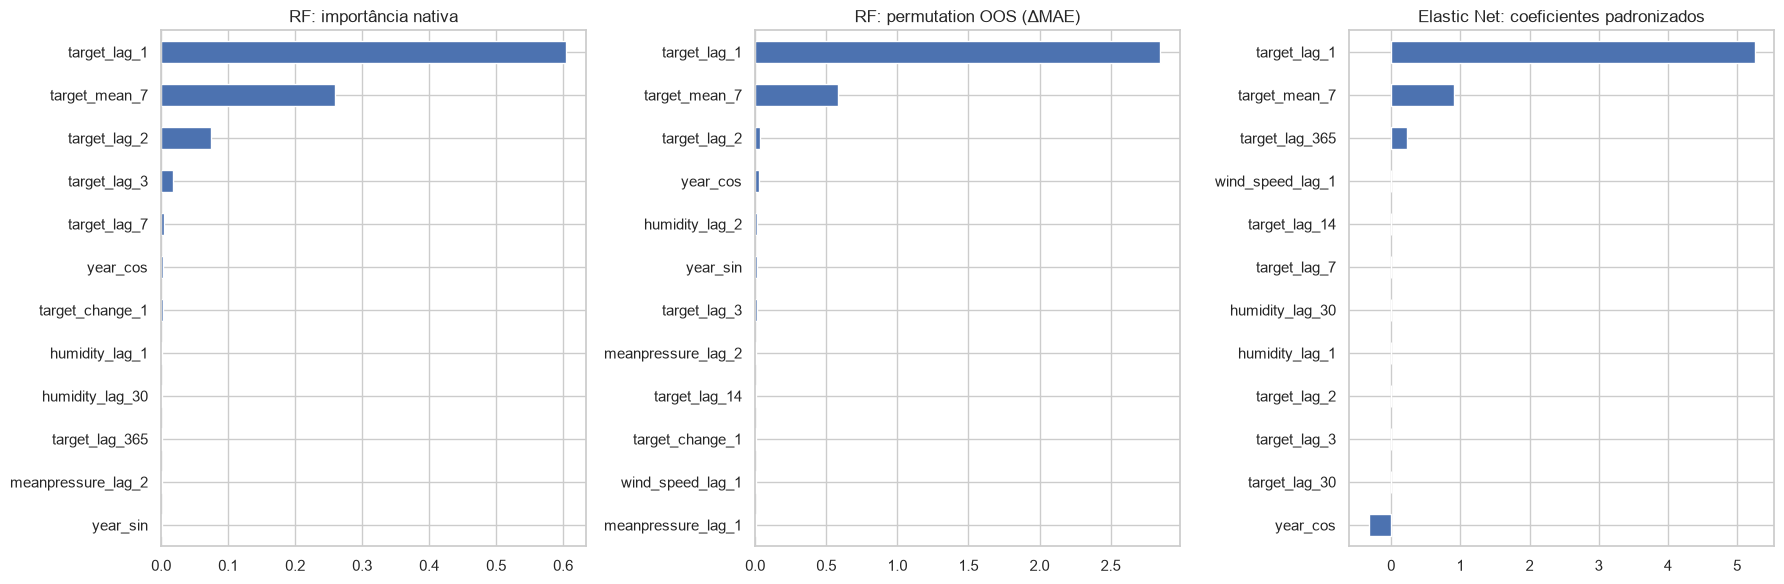

,rf_native,rf_permutation_oos_delta_mae,elastic_net_standardized_coefficient
feature,,,
target_lag_1,0.603924,2.845867,5.254283
target_mean_7,0.259426,0.579576,0.907699
target_lag_2,0.074660,0.032569,0.000000
year_cos,0.003388,0.030107,-0.327573
humidity_lag_2,0.001178,0.011638,-0.000000
year_sin,0.001708,0.009778,0.000000
target_lag_3,0.018136,0.009391,0.000000
meanpressure_lag_2,0.001790,0.008711,-0.000000
target_lag_14,0.001410,0.008399,0.000000


Coeficientes Elastic Net zerados: 30 de 34


,coefficient,p_value
humidity_lag_1,0.018474,0.000917
wind_speed_lag_1,-0.025578,0.030652
meanpressure_lag_1,-0.013965,0.419034
year_sin,0.001566,0.999661
year_cos,-9.724891,0.036899


Holt-Winters é interpretado por nível/tendência/sazonalidade; não há FI tabular.


In [ ]:
full_x = samples[feature_cols]
full_y = samples["target"]

final_rf = clone(rf_base).set_params(**rf_params).fit(full_x, full_y)
final_en = clone(en_base).set_params(**en_params).fit(full_x, full_y)
final_sarimax = SARIMAX(
    full_y,
    exog=samples[sarimax_features],
    order=tuple(sarimax_params["order"]),
    seasonal_order=tuple(sarimax_params["seasonal_order"]),
    trend=sarimax_params["trend"],
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False, maxiter=75)
final_hw = ExponentialSmoothing(
    full_y.to_numpy(),
    trend=hw_params["trend"],
    damped_trend=hw_params["damped_trend"],
    seasonal=hw_params["seasonal"],
    seasonal_periods=hw_params.get("seasonal_periods"),
    initialization_method="estimated",
).fit(optimized=True)

joblib.dump(final_rf, ARTIFACT_DIR / "random_forest.pkl")
joblib.dump(final_en, ARTIFACT_DIR / "elastic_net.pkl")
with open(ARTIFACT_DIR / "sarimax.pkl", "wb") as stream:
    pickle.dump(final_sarimax, stream)
with open(ARTIFACT_DIR / "holt_winters.pkl", "wb") as stream:
    pickle.dump(final_hw, stream)

version_info = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "statsmodels": statsmodels.__version__,
}
selected_params = {
    "sarimax": sarimax_params,
    "holt_winters": hw_params,
    "random_forest": rf_params,
    "elastic_net": en_params,
}
for model_name in model_names:
    metadata = {
        "base_id": BASE_ID,
        "dataset": DATASET_NAME,
        "model": model_name,
        "hyperparams": jsonable(selected_params[model_name]),
        "training_end": str(cleaned["date"].max().date()),
        "trained_at": datetime.now(timezone.utc).isoformat(),
        "random_state": RANDOM_STATE,
        "horizon": HORIZON,
        "strategy": "expanding direct one-step",
        "versions": version_info,
    }
    with open(
        ARTIFACT_DIR / f"{model_name}_meta.json",
        "w",
        encoding="utf-8",
    ) as stream:
        json.dump(metadata, stream, indent=2, ensure_ascii=False)

rf_native = pd.Series(
    final_rf.feature_importances_, index=feature_cols, name="rf_native"
).sort_values(ascending=False)
en_coefficients = pd.Series(
    final_en.named_steps["model"].coef_,
    index=feature_cols,
    name="elastic_net_standardized_coefficient",
).sort_values(key=np.abs, ascending=False)

development_rf = clone(rf_base).set_params(**rf_params).fit(
    development[feature_cols], development["target"]
)
permutation = permutation_importance(
    development_rf,
    test_samples[feature_cols],
    test_samples["target"],
    scoring="neg_mean_absolute_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
)
rf_permutation = pd.Series(
    permutation.importances_mean,
    index=feature_cols,
    name="rf_permutation_oos_delta_mae",
).sort_values(ascending=False)

importance_table = pd.concat(
    [rf_native, rf_permutation, en_coefficients], axis=1
)
importance_table.index.name = "feature"
importance_table.reset_index().to_csv(
    DATA_DIR / f"feature_importance_{BASE_ID}.csv", index=False
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
rf_native.head(12).sort_values().plot.barh(ax=axes[0], title="RF: importância nativa")
rf_permutation.head(12).sort_values().plot.barh(
    ax=axes[1], title="RF: permutation OOS (ΔMAE)"
)
en_coefficients.head(12).sort_values().plot.barh(
    ax=axes[2], title="Elastic Net: coeficientes padronizados"
)
plt.tight_layout()
plt.show()

display(importance_table.sort_values("rf_permutation_oos_delta_mae", ascending=False).head(15))
print(
    "Coeficientes Elastic Net zerados:",
    int((en_coefficients == 0).sum()),
    "de",
    len(en_coefficients),
)

sarimax_interpretation = pd.DataFrame({
    "coefficient": final_sarimax.params,
    "p_value": final_sarimax.pvalues,
})
display(
    sarimax_interpretation.loc[
        sarimax_interpretation.index.intersection(sarimax_features)
    ]
)
print("Holt-Winters é interpretado por nível/tendência/sazonalidade; não há FI tabular.")


### Elastic Net — estudo local

O tuning selecionou `alpha=0,5` e `l1_ratio=1,0`, equivalente ao extremo Lasso da família Elastic Net. O modelo zerou 30 das 34 features. Os maiores coeficientes padronizados foram `target_lag_1` (`5,254`), `target_mean_7` (`0,908`), `year_cos` (`-0,328`) e `target_lag_365` (`0,224`). Isso mostra forte seleção e dependência do passado da própria temperatura.

O Random Forest confirmou essa concentração: `target_lag_1` dominou tanto a importância nativa quanto a permutation OOS, seguido por `target_mean_7`. Lags de umidade, vento e pressão tiveram contribuições bem menores no modelo tabular.

No SARIMAX, `humidity_lag_1` e `wind_speed_lag_1` foram significativos a 5%, enquanto `meanpressure_lag_1` não foi. O harmônico anual `year_cos` também foi significativo. Esses coeficientes devem ser interpretados condicionalmente à dinâmica autorregressiva, não como efeitos causais.

In [ ]:
# Validação final de artefatos e contratos.
required_data = [
    DATA_DIR / f"cleaned_{BASE_ID}.csv",
    DATA_DIR / f"features_{BASE_ID}.parquet",
    DATA_DIR / f"feature_importance_{BASE_ID}.csv",
    DATA_DIR / f"mae_{BASE_ID}.csv",
    DATA_DIR / f"ljung_box_{BASE_ID}.csv",
]
for model_name in model_names:
    required_data.extend([
        DATA_DIR / f"predictions_{model_name}_{BASE_ID}.csv",
        DATA_DIR / f"residuals_{model_name}_{BASE_ID}.csv",
        DATA_DIR / f"hyperparams_{model_name}_{BASE_ID}.json",
    ])
    assert (ARTIFACT_DIR / f"{model_name}.pkl").exists()
    assert (ARTIFACT_DIR / f"{model_name}_meta.json").exists()

assert all(path.exists() and path.stat().st_size > 0 for path in required_data)
assert hashlib.sha256(RAW_FILE.read_bytes()).hexdigest() == raw_sha256_before
assert len(mae_table) == 4
assert mae_table["n_predictions"].nunique() == 1
assert int(mae_table["n_predictions"].iloc[0]) == TEST_OBS
assert np.isfinite(mae_table["mae"]).all()
for model_name, prediction_frame in predictions.items():
    assert np.isfinite(
        prediction_frame[["y_true", "y_pred"]].to_numpy()
    ).all(), f"Previsão não finita em {model_name}."
assert len(ljung_table) == len(model_names) * 2
assert np.isfinite(ljung_table[["lb_stat", "p_value"]].to_numpy()).all()

print(
    f"VALIDAÇÃO FINAL OK: {len(required_data)} arquivos de dados e "
    f"{len(model_names) * 2} artefatos de modelo."
)
print("Raw preservado; chaves OOS alinhadas; notebook sem estado oculto.")


VALIDAÇÃO FINAL OK: 17 arquivos de dados e 8 artefatos de modelo.
Raw preservado; chaves OOS alinhadas; notebook sem estado oculto.
